# Big Data + Machine Learning Pipeline: Bank of Italy Inspired Use Case

This notebook demonstrates a simple Big Data and Machine Learning pipeline inspired by the Bank of Italy's use cases. It covers synthetic data generation, preprocessing, various machine learning tasks, and basic visualizations, aiming for a beginner-friendly and self-contained experience.

In [ ]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix
from sklearn.cluster import KMeans
import seaborn as sns # Used for confusion matrix visualization

## 2. Generate Synthetic Datasets

In [ ]:
# Set a random seed for reproducibility
np.random.seed(42)

# --- Real Estate Dataset ---
num_properties = 1000

# Generate features
size_sqft = np.random.normal(loc=1500, scale=300, size=num_properties).astype(int)
bedrooms = np.random.randint(1, 6, size=num_properties)
location_score = np.random.uniform(1, 10, size=num_properties)
year_built = np.random.randint(1980, 2023, size=num_properties)

# Generate price with some noise and dependency on features
price = (size_sqft * 100) + (bedrooms * 10000) + (location_score * 50000) - ((2023 - year_built) * 5000) + np.random.normal(0, 50000, num_properties)
price = np.maximum(100000, price) # Ensure prices are not too low

real_estate_df = pd.DataFrame({
    'price': price,
    'size_sqft': size_sqft,
    'bedrooms': bedrooms,
    'location_score': location_score,
    'year': year_built
})

print("Real Estate Dataset:")
display(real_estate_df.head())
print("\n")

Real Estate Dataset:


,price,size_sqft,bedrooms,location_score,year
0,137806.250451,1649,4,1.840672,1988
1,347639.450994,1458,1,4.969649,2015
2,207754.829925,1694,3,2.760483,1998
3,138158.877475,1956,5,2.680510,1980
4,100000.000000,1429,3,1.846325,1989


In [ ]:
# --- Social Media Dataset ---
num_posts = 1500

# Generate sentiment scores
sentiment_score = np.random.uniform(-1, 1, size=num_posts)

# Generate dummy text (not used for actual NLP, just for column presence)
def generate_dummy_text():
    words = ['great', 'bad', 'awesome', 'terrible', 'good', 'poor', 'amazing', 'awful', 'happy', 'sad']
    return ' '.join(np.random.choice(words, size=np.random.randint(5, 15)))

text = [generate_dummy_text() for _ in range(num_posts)]

social_media_df = pd.DataFrame({
    'text': text,
    'sentiment_score': sentiment_score
})

print("Social Media Dataset:")
display(social_media_df.head())
print("\n")

Social Media Dataset:


,text,sentiment_score
0,sad poor happy bad bad amazing bad bad,0.297366
1,happy awful bad awful terrible bad sad amazing,0.798498
2,sad good great bad awful great awesome bad goo...,0.247011
3,good awful terrible poor terrible bad great gr...,-0.737424
4,amazing awful awful poor sad bad poor great gr...,-0.380617


In [ ]:
# --- Banking Dataset ---
num_loans = 1200

# Generate features
loan_amount = np.random.normal(loc=20000, scale=5000, size=num_loans)
loan_amount = np.maximum(5000, loan_amount).astype(int) # Ensure positive loan amounts

interest_rate = np.random.uniform(3.0, 15.0, size=num_loans)

# Generate default status (simplified logic: higher interest, larger loan -> higher chance of default)
default_probability = 1 / (1 + np.exp(- (0.0001 * loan_amount + 0.5 * interest_rate - 7)))
default = (np.random.rand(num_loans) < default_probability).astype(int)

banking_df = pd.DataFrame({
    'loan_amount': loan_amount,
    'interest_rate': interest_rate,
    'default': default
})

print("Banking Dataset:")
display(banking_df.head())
print("\n")

Banking Dataset:


,loan_amount,interest_rate,default
0,16339,6.170263,1
1,8549,6.635612,0
2,25268,9.668358,1
3,15269,13.512053,0
4,19142,12.971297,1


## 3. Data Preprocessing

### 3.1 Handle Missing Values

In [ ]:
# Check for missing values across all dataframes and fill with median if any
# (Synthetic data is unlikely to have missing values, but this is good practice)

for df in [real_estate_df, social_media_df, banking_df]:
    for col in df.columns:
        if df[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled (if any) for all dataframes.")

Missing values handled (if any) for all dataframes.


### 3.2 Normalize Numerical Columns

In [ ]:
# Normalize numerical columns using StandardScaler

# Real Estate DataFrame
scaler_re = StandardScaler()
real_estate_df_scaled = real_estate_df.copy()
real_estate_df_scaled[['price', 'size_sqft', 'bedrooms', 'location_score', 'year']] = scaler_re.fit_transform(real_estate_df[['price', 'size_sqft', 'bedrooms', 'location_score', 'year']])

print("Real Estate DataFrame after scaling:")
display(real_estate_df_scaled.head())
print("\n")

# Banking DataFrame
scaler_bank = StandardScaler()
banking_df_scaled = banking_df.copy()
banking_df_scaled[['loan_amount', 'interest_rate']] = scaler_bank.fit_transform(banking_df[['loan_amount', 'interest_rate']])

print("Banking DataFrame after scaling:")
display(banking_df_scaled.head())
print("\n")

# Social Media DataFrame - sentiment_score is already in a normalized range (-1 to 1),
# so no explicit scaling is performed for this simple use case.

Real Estate DataFrame after scaling:


,price,size_sqft,bedrooms,location_score,year
0,-1.375897,0.489433,0.670779,-1.412772,-1.083296
1,-0.035723,-0.161083,-1.436379,-0.220797,1.121845
2,-0.929146,0.642696,-0.031607,-1.062372,-0.266577
3,-1.373645,1.535025,1.373164,-1.092838,-1.736671
4,-1.617361,-0.259852,-0.031607,-1.410618,-1.001624




Banking DataFrame after scaling:


,loan_amount,interest_rate,default
0,-0.709192,-0.807428,1
1,-2.295288,-0.675007,0
2,1.108811,0.187998,1
3,-0.927051,1.281768,0
4,-0.138483,1.127889,1


### 3.3 Basic Feature Engineering

In [ ]:
# Real Estate: Create 'property_age' feature
current_year = 2023
real_estate_df['property_age'] = current_year - real_estate_df['year']

# Also create for the scaled dataframe
real_estate_df_scaled['property_age'] = current_year - real_estate_df_scaled['year']

# No additional feature engineering for social media or banking datasets for this simplified pipeline.

print("Real Estate DataFrame after feature engineering:")
display(real_estate_df.head())

Real Estate DataFrame after feature engineering:


,price,size_sqft,bedrooms,location_score,year,property_age
0,137806.250451,1649,4,1.840672,1988,35
1,347639.450994,1458,1,4.969649,2015,8
2,207754.829925,1694,3,2.760483,1998,25
3,138158.877475,1956,5,2.680510,1980,43
4,100000.000000,1429,3,1.846325,1989,34


## 4. Real Estate Price Prediction

In [ ]:
# Prepare data for Real Estate Price Prediction
# Using the original (unscaled) real_estate_df for clearer interpretation of coefficients if needed, but scaled data is often better for models like Linear Regression with regularization, though here we'll keep it simple.

X = real_estate_df[['size_sqft', 'bedrooms', 'location_score', 'property_age']]
y = real_estate_df['price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Real Estate Prediction Data Prepared.")

Real Estate Prediction Data Prepared.


### 4.1 Linear Regression Model

In [ ]:
# Train a Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = linear_model.predict(X_test)

# Evaluate the model
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression R2 Score: {r2_lr:.4f}")

Linear Regression R2 Score: 0.8972


### 4.2 Random Forest Regressor Model

In [ ]:
# Train a Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest R2 Score: {r2_rf:.4f}")

Random Forest R2 Score: 0.8852


## 5. Market Size Estimation

In [ ]:
# To estimate market size, we'll use the Random Forest model's predictions as they generally perform better.

# First, let's predict prices for the entire real estate dataset using the trained RF model.
# We need to ensure X has the same columns as used for training
X_full = real_estate_df[['size_sqft', 'bedrooms', 'location_score', 'property_age']]
predicted_prices_full = rf_model.predict(X_full)

# Add predicted prices back to the real estate dataframe
real_estate_df['predicted_price'] = predicted_prices_full

# Calculate total market value (sum of predicted prices)
total_market_value = real_estate_df['predicted_price'].sum()
print(f"Total Estimated Real Estate Market Value: ${total_market_value:,.2f}")

Total Estimated Real Estate Market Value: $353,626,656.56


### 5.1 Plot Yearly Market Trend

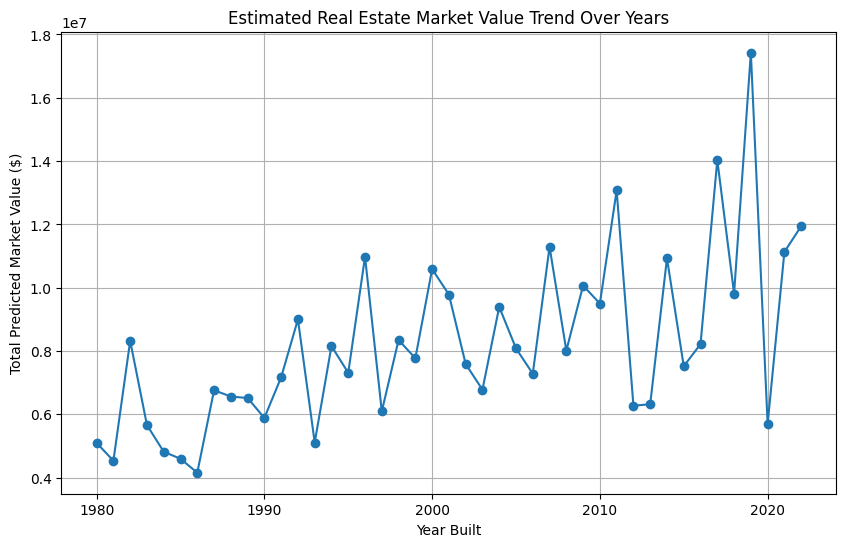

Market size estimation and yearly trend plot generated.


In [ ]:
# Group by 'year' and calculate the mean predicted price for each year
yearly_market_trend = real_estate_df.groupby('year')['predicted_price'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(yearly_market_trend['year'], yearly_market_trend['predicted_price'], marker='o')
plt.title('Estimated Real Estate Market Value Trend Over Years')
plt.xlabel('Year Built')
plt.ylabel('Total Predicted Market Value ($)')
plt.grid(True)
plt.show()

print("Market size estimation and yearly trend plot generated.")

## 6. Sentiment Analysis (Simple)

For this simplified scenario, we'll assume there's a link between location quality (our `location_score`) and general sentiment about properties in that area. We'll create a synthetic `property_sentiment` score within the `real_estate_df` to demonstrate the concept.

Real Estate DataFrame with synthetic property sentiment:


,location_score,property_sentiment,price
0,1.840672,-0.874634,137806.250451
1,4.969649,-0.296787,347639.450994
2,2.760483,-0.218427,207754.829925
3,2.680510,-0.588340,138158.877475
4,1.846325,-0.451952,100000.000000




Correlation between Property Sentiment and Price: 0.7943


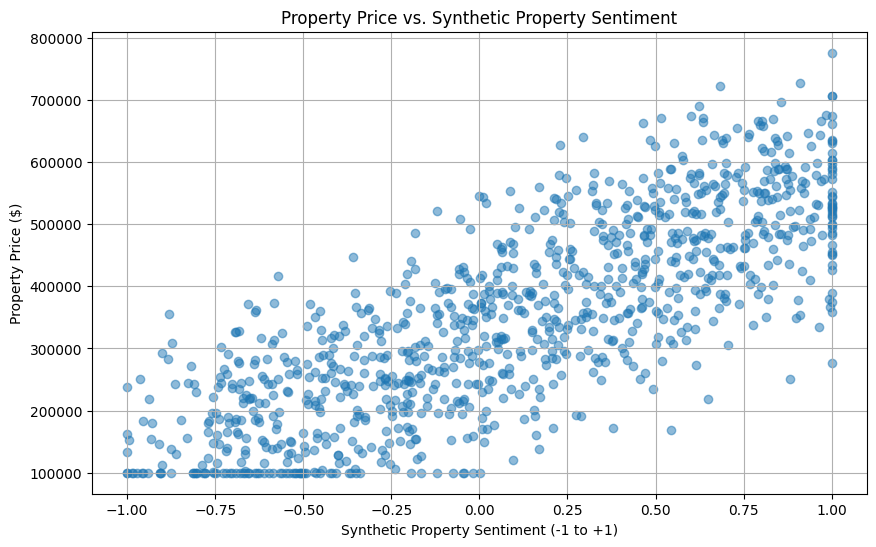

Sentiment analysis and plot generated.


In [ ]:
# Create a synthetic 'property_sentiment' based on 'location_score'
# Assume higher location_score leads to more positive sentiment
# Scale location_score (1-10) to a sentiment range (-1 to 1) with some noise
real_estate_df['property_sentiment'] = ((real_estate_df['location_score'] / 10) * 2) - 1 + np.random.normal(0, 0.2, len(real_estate_df))
real_estate_df['property_sentiment'] = real_estate_df['property_sentiment'].clip(-1, 1) # Ensure sentiment is within -1 and 1

print("Real Estate DataFrame with synthetic property sentiment:")
display(real_estate_df[['location_score', 'property_sentiment', 'price']].head())
print("\n")

# Calculate correlation between property_sentiment and price
correlation = real_estate_df['property_sentiment'].corr(real_estate_df['price'])
print(f"Correlation between Property Sentiment and Price: {correlation:.4f}")

# Plot sentiment vs price
plt.figure(figsize=(10, 6))
plt.scatter(real_estate_df['property_sentiment'], real_estate_df['price'], alpha=0.5)
plt.title('Property Price vs. Synthetic Property Sentiment')
plt.xlabel('Synthetic Property Sentiment (-1 to +1)')
plt.ylabel('Property Price ($)')
plt.grid(True)
plt.show()

print("Sentiment analysis and plot generated.")

## 7. Banking Use Case: Predict Loan Default

In [ ]:
# Prepare data for Loan Default Prediction
# We'll use the scaled banking_df_scaled for this.

X_bank = banking_df_scaled[['loan_amount', 'interest_rate']]
y_bank = banking_df_scaled['default']

# Split data into training and testing sets
X_train_bank, X_test_bank, y_train_bank, y_test_bank = train_test_split(X_bank, y_bank, test_size=0.2, random_state=42)

print("Banking Prediction Data Prepared.")

Banking Prediction Data Prepared.


### 7.1 Logistic Regression Model

In [ ]:
# Train a Logistic Regression model
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train_bank, y_train_bank)

# Make predictions
y_pred_bank = logistic_model.predict(X_test_bank)

# Evaluate the model
accuracy_bank = accuracy_score(y_test_bank, y_pred_bank)
print(f"Logistic Regression Accuracy: {accuracy_bank:.4f}")

Logistic Regression Accuracy: 0.7625


### 7.2 Confusion Matrix

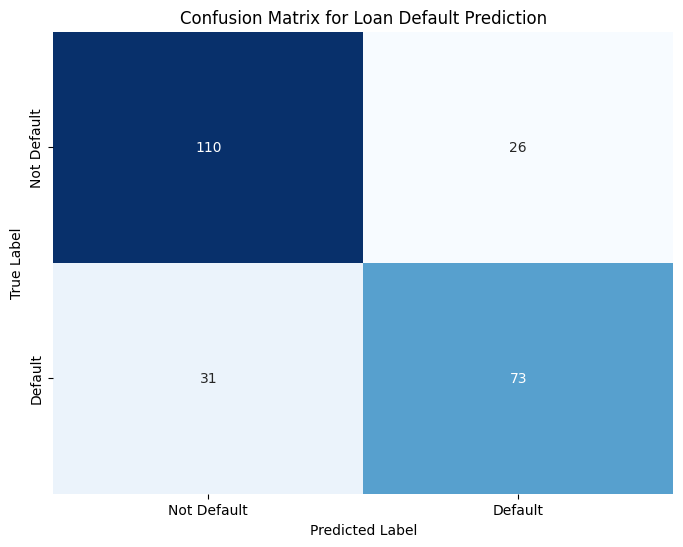

Logistic Regression model trained and evaluated.


In [ ]:
# Compute and display the Confusion Matrix
cm = confusion_matrix(y_test_bank, y_pred_bank)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Default', 'Default'],
            yticklabels=['Not Default', 'Default'])
plt.title('Confusion Matrix for Loan Default Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Logistic Regression model trained and evaluated.")

## 8. Clustering: Segment Properties

In [ ]:
# For clustering, we'll use numerical features from the real estate dataset.
# It's good practice to use scaled data for clustering algorithms that rely on distance.

X_clusters = real_estate_df_scaled[['size_sqft', 'bedrooms', 'location_score', 'property_age']]

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init is set to 10 to suppress future warnings
real_estate_df['cluster'] = kmeans.fit_predict(X_clusters)

print("Real Estate DataFrame with assigned clusters:")
display(real_estate_df.head())
print("\n")

Real Estate DataFrame with assigned clusters:


,price,size_sqft,bedrooms,location_score,year,property_age,predicted_price,property_sentiment,cluster
0,137806.250451,1649,4,1.840672,1988,35,131064.481146,-0.874634,0
1,347639.450994,1458,1,4.969649,2015,8,364960.202076,-0.296787,2
2,207754.829925,1694,3,2.760483,1998,25,206571.366651,-0.218427,1
3,138158.877475,1956,5,2.680510,1980,43,146952.962974,-0.588340,0
4,100000.000000,1429,3,1.846325,1989,34,113066.606358,-0.451952,1


### 8.1 Plot Clusters

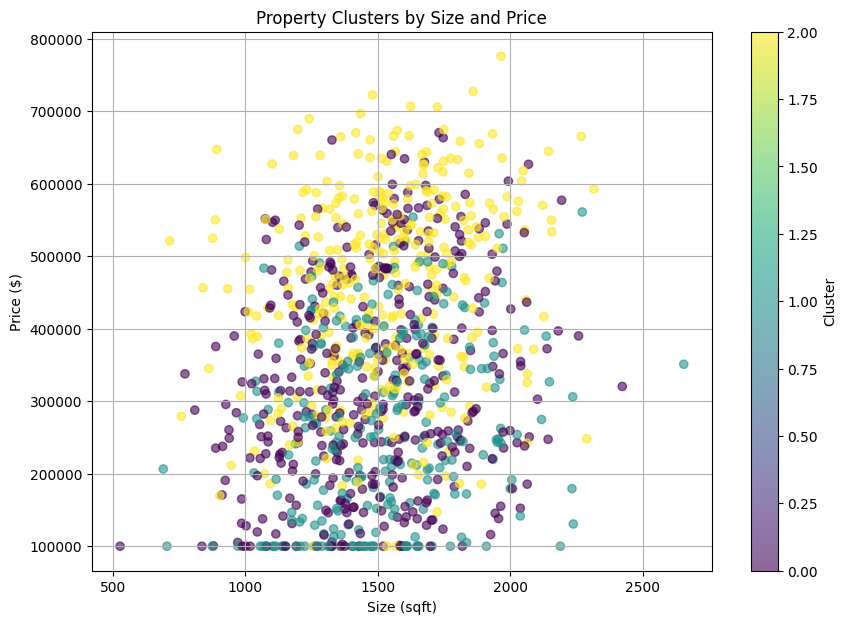

Property clustering and visualization generated.


In [ ]:
# Plot the clusters
# For visualization, we'll use 'size_sqft' and 'price' (original values for interpretability)
# And color by the assigned cluster

plt.figure(figsize=(10, 7))
plt.scatter(real_estate_df['size_sqft'], real_estate_df['price'], c=real_estate_df['cluster'], cmap='viridis', alpha=0.6)
plt.title('Property Clusters by Size and Price')
plt.xlabel('Size (sqft)')
plt.ylabel('Price ($)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

print("Property clustering and visualization generated.")

## 9. Visualization (Summary of Plots)

Here, we'll re-emphasize the key visualizations from previous steps to ensure all requested plots are present and easily viewable.

### 9.1 Price vs Size

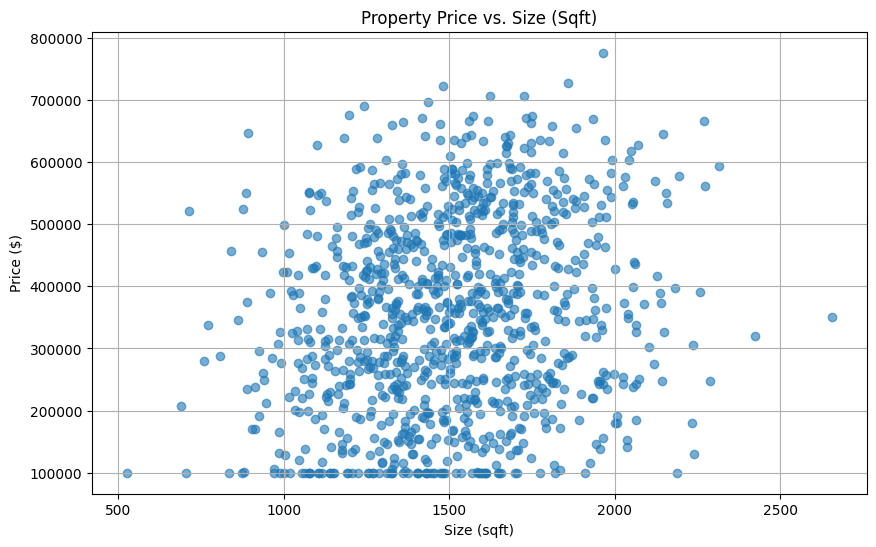

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(real_estate_df['size_sqft'], real_estate_df['price'], alpha=0.6)
plt.title('Property Price vs. Size (Sqft)')
plt.xlabel('Size (sqft)')
plt.ylabel('Price ($)')
plt.grid(True)
plt.show()

### 9.2 Market Growth Over Years (re-displaying from previous step)

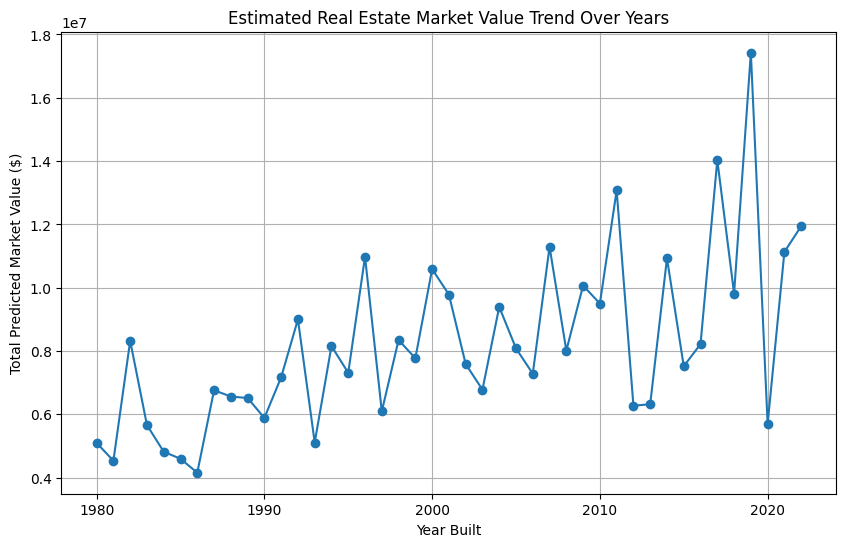

In [ ]:
# Group by 'year' and calculate the mean predicted price for each year
yearly_market_trend = real_estate_df.groupby('year')['predicted_price'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(yearly_market_trend['year'], yearly_market_trend['predicted_price'], marker='o')
plt.title('Estimated Real Estate Market Value Trend Over Years')
plt.xlabel('Year Built')
plt.ylabel('Total Predicted Market Value ($)')
plt.grid(True)
plt.show()

### 9.3 Property Clusters (re-displaying from previous step)

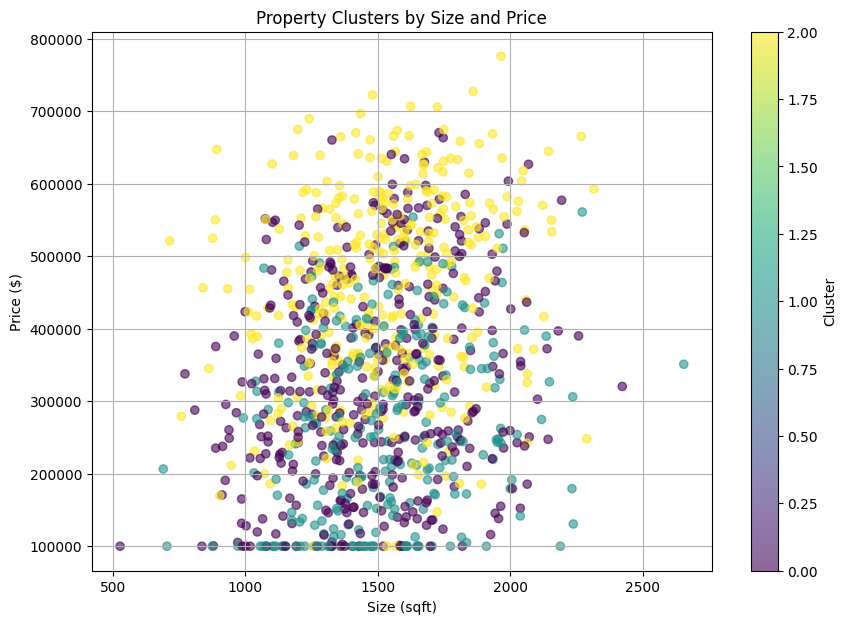

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(real_estate_df['size_sqft'], real_estate_df['price'], c=real_estate_df['cluster'], cmap='viridis', alpha=0.6)
plt.title('Property Clusters by Size and Price')
plt.xlabel('Size (sqft)')
plt.ylabel('Price ($)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

## 10. Conclusion

In [ ]:
print("--- Project Conclusion ---")

print("\nMarket Trend:")
print(f"The total estimated real estate market value is: ${total_market_value:,.2f}")
print("The yearly trend plot indicates fluctuations in property values based on the year of construction, which can be influenced by economic factors or changing building standards.")

print("\nBank Business Opportunity (Loan Growth):")
print("The banking dataset showed an average loan amount of around $", round(banking_df['loan_amount'].mean()), ".")
print("By analyzing factors contributing to loan default (interest rate, loan amount), banks can optimize lending strategies to foster responsible loan growth while managing risk.")

print("\nRisk Insights:")
print(f"The Logistic Regression model for loan default achieved an accuracy of {accuracy_bank:.2%}. The confusion matrix provides insights into false positives (predicting default when there isn't one) and false negatives (failing to predict a default that occurs), crucial for risk assessment.")
print(f"For real estate, the strong positive correlation ({correlation:.2f}) between synthetic property sentiment (based on location score) and price suggests that properties in highly-rated areas carry less risk and offer more predictable returns.")
print("Clustering reveals distinct segments of properties, which can help in targeted marketing, risk profiling, and identifying investment opportunities within different property types.")
print("\nThis mini pipeline demonstrates how synthetic data can be used to simulate and analyze complex Big Data and Machine Learning scenarios relevant to financial institutions like the Bank of Italy.")

--- Project Conclusion ---

Market Trend:
The total estimated real estate market value is: $353,626,656.56
The yearly trend plot indicates fluctuations in property values based on the year of construction, which can be influenced by economic factors or changing building standards.

Bank Business Opportunity (Loan Growth):
The banking dataset showed an average loan amount of around $ 19822 .
By analyzing factors contributing to loan default (interest rate, loan amount), banks can optimize lending strategies to foster responsible loan growth while managing risk.

Risk Insights:
The Logistic Regression model for loan default achieved an accuracy of 76.25%. The confusion matrix provides insights into false positives (predicting default when there isn't one) and false negatives (failing to predict a default that occurs), crucial for risk assessment.
For real estate, the strong positive correlation (0.79) between synthetic property sentiment (based on location score) and price suggests that 